# KNN Baseline

In [36]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Data

In [37]:
data_dir_candidates = [Path("../../data/processed"), Path("data/processed")]
DATA_DIR = next(path for path in data_dir_candidates if path.exists())
TARGET_COLUMN = "Y"
ID_COLUMNS = ["Drug_ID", "Drug", "canonical_smiles", "mol"]

train_df = pd.read_csv(DATA_DIR / "train.csv")
valid_df = pd.read_csv(DATA_DIR / "valid.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

display(pd.DataFrame({
    "split": ["train", "valid", "test"],
    "rows": [len(train_df), len(valid_df), len(test_df)],
    "columns": [train_df.shape[1], valid_df.shape[1], test_df.shape[1]],
}))

,split,rows,columns
0,train,5170,1817
1,valid,738,1817
2,test,1477,1817


## Preprocessing

In [38]:
def split_features_target(df):
    y = pd.to_numeric(df[TARGET_COLUMN], errors="raise").to_numpy()
    columns_to_drop = [TARGET_COLUMN, *[col for col in ID_COLUMNS if col in df.columns]]
    X = df.drop(columns=columns_to_drop)
    return X, y


X_train, y_train = split_features_target(train_df)
X_valid, y_valid = split_features_target(valid_df)
X_test, y_test = split_features_target(test_df)

bool_columns = X_train.select_dtypes(include=["bool"]).columns.tolist()
for X in [X_train, X_valid, X_test]:
    X[bool_columns] = X[bool_columns].astype("int8")

numeric_columns = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_columns),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_columns),
    ],
    remainder="drop",
)

X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)
X_test_processed = preprocessor.transform(X_test)

display(pd.DataFrame({
    "split": ["train", "valid", "test"],
    "processed_shape": [
        X_train_processed.shape,
        X_valid_processed.shape,
        X_test_processed.shape,
    ],
}))

,split,processed_shape
0,train,"(5170, 1813)"
1,valid,"(738, 1813)"
2,test,"(1477, 1813)"


## Baseline Model

In [39]:
knn = KNeighborsRegressor(n_neighbors=20)
knn.fit(X_train_processed, y_train)

valid_pred = knn.predict(X_valid_processed)
test_pred = knn.predict(X_test_processed)

## Results

In [40]:
def regression_metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


metrics = pd.DataFrame([
    {"split": "valid", **regression_metrics(y_valid, valid_pred)},
    {"split": "test", **regression_metrics(y_test, test_pred)},
]).set_index("split")

display(metrics.style.format({"RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"}))

,RMSE,MAE,R2
split,,,
valid,0.7030,0.5111,0.4835
test,0.6635,0.4858,0.5072


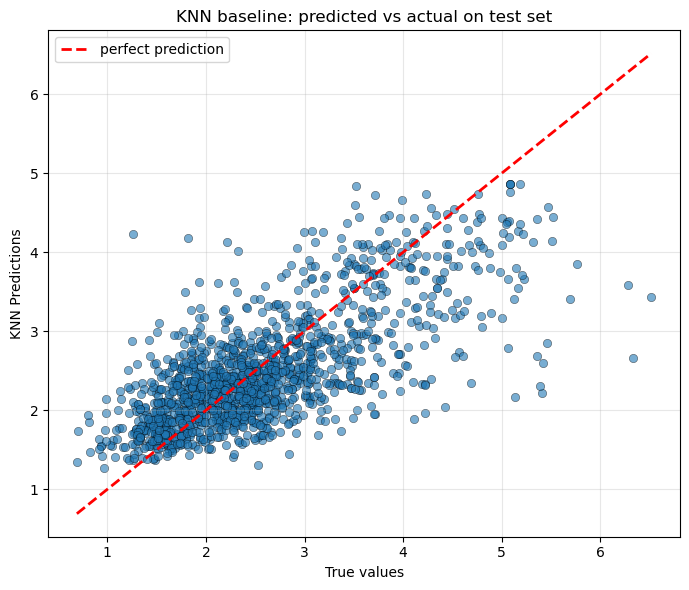

In [41]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, test_pred, alpha=0.6, edgecolors="black", linewidths=0.4)

limits = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
plt.plot(limits, limits, "r--", linewidth=2, label="perfect prediction")

plt.xlabel("True values")
plt.ylabel("KNN Predictions")
plt.title("KNN baseline: predicted vs actual on test set")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
comparison = pd.DataFrame({
    "real": y_test,
    "predicted": test_pred,
    "absolute_error": np.abs(y_test - test_pred),
})

display(comparison.head(10).style.format({
    "real": "{:.4f}",
    "predicted": "{:.4f}",
    "absolute_error": "{:.4f}",
}))

,real,predicted,absolute_error
0,3.1140,3.0562,0.0578
1,2.1250,2.5266,0.4016
2,3.4660,3.0018,0.4642
3,3.1850,4.2580,1.0730
4,1.8670,1.9631,0.0961
5,1.8190,1.8241,0.0051
6,1.4950,1.7270,0.2320
7,2.3190,2.2977,0.0213
8,2.4990,2.2556,0.2434
9,3.5970,2.9472,0.6498
